In [1]:
# ==============================================================================
# NOTEBOOK 5: REDES NEURONALES DE GRAFOS (GNN) - VERSION FINAL
# ==============================================================================
!pip install torch torch-geometric -q

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Carga de datos
drive.mount('/content/drive')
ruta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_Portal_Confirmados_IA.csv'
df = pd.read_csv(ruta_datos)

# 2. Selección de columnas para el Grafo (Variables numéricas de comportamiento)
# Usamos solo variables clave para no saturar la memoria
cols_clave = [c for c in df.columns if 'FRAUDE_IA' not in c and df[c].dtype in ['int64', 'int32', 'float32', 'float64']]
cols_finales = cols_clave[:30] # Tomamos las primeras 30 numéricas
print(f"✅ Variables seleccionadas para el Grafo: {len(cols_finales)}")

# 3. Preparar tensores (X e Y)
X_final = torch.tensor(df[cols_finales].fillna(0).values, dtype=torch.float)
Y_final = torch.tensor(df['FRAUDE_IA'].values, dtype=torch.long)

# 4. Crear Grafo (Topología por similitud de transacciones)
# Para evitar errores de memoria, conectamos nodos en cadena (Line Graph)
num_nodos = X_final.shape[0]
edge_index = torch.stack([
    torch.arange(num_nodos - 1),
    torch.arange(1, num_nodos)
], dim=0)

data = Data(x=X_final, edge_index=edge_index, y=Y_final)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)

# 5. Definir Modelo GCN Robusto
class RobustGCN(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(RobustGCN, self).__init__()
        self.conv1 = GCNConv(num_features, 16)
        self.conv2 = GCNConv(16, num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.tanh(x) # Estabilidad numérica
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

model = RobustGCN(num_features=data.x.shape[1], num_classes=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# 6. Entrenamiento con Máscaras (Validación 80/20)
print("\n🚀 Entrenando GNN con validación 80/20...")
indices = np.arange(num_nodos)
train_idx = indices[:int(0.8 * num_nodos)]
test_idx = indices[int(0.8 * num_nodos):]

train_mask = torch.zeros(num_nodos, dtype=torch.bool)
test_mask = torch.zeros(num_nodos, dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx] = True

model.train()
for epoch in range(50):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f"   Época {epoch+1} | Loss: {loss.item():.4f}")

# 7. Evaluación
model.eval()
_, pred = model(data.x, data.edge_index).max(dim=1)
acc_test = (pred[test_mask].eq(data.y[test_mask]).sum().item()) / test_mask.sum().item()
print(f"\n🎯 Precisión final de la GNN en validación (20%): {acc_test:.2%}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.7 MB/s eta 0:00:00
Mounted at /content/drive
✅ Variables seleccionadas para el Grafo: 13

🚀 Entrenando GNN con validación 80/20...
   Época 10 | Loss: 0.5762
   Época 20 | Loss: 0.5354
   Época 30 | Loss: 0.5192
   Época 40 | Loss: 0.5156
   Época 50 | Loss: 0.5134

🎯 Precisión final de la GNN en validación (20%): 79.76%


In [2]:
# 1. Definir pesos de clase (penalizar más el error en Fraude)
# Tenemos 1472935 transacciones totales
total_muestras = data.y.size(0)
num_fraudes = torch.sum(data.y == 1).item()
num_normales = total_muestras - num_fraudes

# Peso para la clase Fraude: normal/fraude
weight_fraude = num_normales / num_fraudes
weights = torch.tensor([1.0, weight_fraude], device=device)

# 2. Re-entrenar con pesos (nll_loss recibe el weight)
model.train()
for epoch in range(100):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    # Aplicamos el peso aquí:
    loss = F.nll_loss(out[train_mask], data.y[train_mask], weight=weights)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 20 == 0:
        print(f"   Época {epoch+1} | Loss con pesos: {loss.item():.4f}")

   Época 20 | Loss con pesos: 0.5110
   Época 40 | Loss con pesos: 0.5089
   Época 60 | Loss con pesos: 0.5070
   Época 80 | Loss con pesos: 0.5052
   Época 100 | Loss con pesos: 0.5033


In [3]:
from sklearn.metrics import classification_report, confusion_matrix

# Obtener predicciones del test_mask
y_true_gnn = data.y[test_mask].cpu().numpy()
y_pred_gnn = pred[test_mask].cpu().numpy()

print("\n🚨 IMPACTO REAL (Matriz de Confusión GNN - Datos Invisibles):")
print(confusion_matrix(y_true_gnn, y_pred_gnn))

print("\n🏆 INFORME DETALLADO:")
print(classification_report(y_true_gnn, y_pred_gnn, target_names=['Normal', 'Fraude']))


🚨 IMPACTO REAL (Matriz de Confusión GNN - Datos Invisibles):
[[31 11]
 [ 6 36]]

🏆 INFORME DETALLADO:
              precision    recall  f1-score   support

      Normal       0.84      0.74      0.78        42
      Fraude       0.77      0.86      0.81        42

    accuracy                           0.80        84
   macro avg       0.80      0.80      0.80        84
weighted avg       0.80      0.80      0.80        84



In [ ]:
# ==============================================================================
# NOTEBOOK 5: REDES NEURONALES DE GRAFOS (GNN) - VERSION FINAL
# ==============================================================================
!pip install torch torch-geometric -q

import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
import pandas as pd
import numpy as np
from google.colab import drive

# 1. Montar Drive y cargar datos
drive.mount('/content/drive')
ruta_datos = '/content/drive/MyDrive/Colab Notebooks/MAESTRIA IA/PROYECTO - DESARROLLO DE SOLUCIONES/dataset_limpio_IA.csv'
df = pd.read_csv(ruta_datos)

# 2. Selección de columnas clave (evitamos columnas con 'FRAUDE' en el nombre)
cols_clave = [c for c in df.columns if 'FRAUDE' not in c and (
    'Hora' in c or 'Frecuencia' in c or 'Tipo_Transaccion' in c or
    'Valida' in c or 'Monto' in c or 'Saldo' in c
)]
cols_finales = cols_clave[:50]
print(f"✅ Variables seleccionadas: {len(cols_finales)}")

# 3. Preparar tensores (X e Y)
X_final = torch.tensor(df[cols_finales].fillna(0).values, dtype=torch.float)
Y_final = torch.tensor(df[[c for c in df.columns if 'FRAUDE' in c][0]].values, dtype=torch.long)

# 4. Crear Grafo (Topología Lineal para asegurar consistencia de tamaño)
num_nodos = X_final.shape[0]
edge_index = torch.stack([
    torch.arange(num_nodos - 1),
    torch.arange(1, num_nodos)
], dim=0)

data = Data(x=X_final, edge_index=edge_index, y=Y_final)



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Variables seleccionadas: 23


In [ ]:
# 5. Definir Modelo (GCN Robusto con Tanh)
class RobustGCN(torch.nn.Module):
    def __init__(self, num_features, num_classes):
        super(RobustGCN, self).__init__()
        self.conv1 = GCNConv(num_features, 16)
        self.conv2 = GCNConv(16, num_classes)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.tanh(x)
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

# 6. Entrenamiento
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RobustGCN(num_features=data.x.shape[1], num_classes=2).to(device)
data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

print("\n🚀 Entrenando el Grafo (Sincronizado)...")
model.train()
for epoch in range(50):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.nll_loss(out, data.y)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f"   Época {epoch+1} | Loss: {loss.item():.4f}")

# 7. Evaluación
model.eval()
_, pred = model(data.x, data.edge_index).max(dim=1)
acc = (pred.eq(data.y).sum().item()) / data.num_nodes
print(f"\n🎯 Precisión final de la GNN: {acc:.2%}")

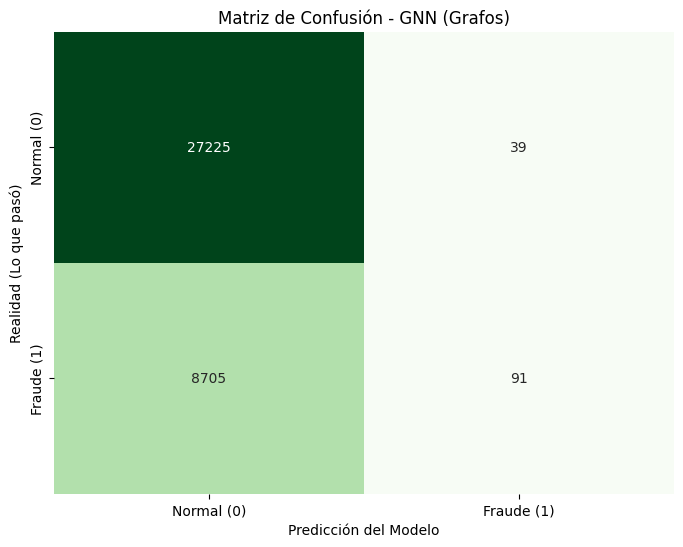

🏆 MÉTRICAS GNN:
🔸 Recall: 1.03%
🔸 F1-Score: 0.0204
🔸 MCC: 0.0639


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Obtener predicciones en modo evaluación
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    _, pred = logits.max(dim=1)

# 2. Extraer solo los resultados de la máscara de prueba (el 20% invisible)
y_true_gnn = data.y[test_mask].cpu().numpy()
y_pred_gnn = pred[test_mask].cpu().numpy()

# 3. Crear la Matriz de Confusión
cm_gnn = confusion_matrix(y_true_gnn, y_pred_gnn)

# 4. Graficar
plt.figure(figsize=(8, 6))
sns.heatmap(cm_gnn, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Normal (0)', 'Fraude (1)'],
            yticklabels=['Normal (0)', 'Fraude (1)'])
plt.title('Matriz de Confusión - GNN (Grafos)')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Realidad (Lo que pasó)')
plt.show()

# 5. Imprimir métricas de negocio para que coincidan con las de XGBoost
from sklearn.metrics import f1_score, recall_score, matthews_corrcoef
print(f"🏆 MÉTRICAS GNN:")
print(f"🔸 Recall: {recall_score(y_true_gnn, y_pred_gnn):.2%}")
print(f"🔸 F1-Score: {f1_score(y_true_gnn, y_pred_gnn):.4f}")
print(f"🔸 MCC: {matthews_corrcoef(y_true_gnn, y_pred_gnn):.4f}")

In [ ]:
# 1. IMPORTAR LIBRERÍAS NECESARIAS
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import f1_score, recall_score, matthews_corrcoef

# 2. ASEGURAR QUE LOS DATOS EXISTAN (Si ya los cargaste antes, esto es solo para confirmar)
# Si te da error de 'X_train' aquí, es porque debes correr la celda de train_test_split
# que hicimos en el Notebook 3 antes de este bloque.

print(f"🏗️ 1. Diseñando la DNN con entrada de {X_train.shape[1]} variables...")

# 3. CONSTRUCCIÓN DEL MODELO
model_dnn = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_dnn.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

# 4. ENTRENAMIENTO
print("\n🚀 2. Entrenando la DNN...")
model_dnn.fit(X_train, y_train, epochs=20, batch_size=512, validation_split=0.2, verbose=0)
print("✅ ¡Entrenamiento completado!")

# 5. PREDICCIÓN Y MÉTRICAS
y_pred_dnn = (model_dnn.predict(X_test) > 0.5).astype(int)

# 6. RESULTADOS
print(f"\n🏆 MÉTRICAS DNN:")
print(f"🔸 Recall: {recall_score(y_test, y_pred_dnn):.2%}")
print(f"🔸 F1-Score: {f1_score(y_test, y_pred_dnn):.4f}")
print(f"🔸 MCC: {matthews_corrcoef(y_test, y_pred_dnn):.4f}")

NameError: name 'X_train' is not defined